In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import os
from torch.utils.tensorboard import SummaryWriter

# configure device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.cuda.is_available())

# define global paths and names
DATASET_PATH = '/home/nfs/inf6/data/datasets/MOVi/movi_c'
TRAIN_PATH = DATASET_PATH + "/train"
VALIDATION_PATH = DATASET_PATH + "/validation"

# set up tensorboard
MODEL_NAME = "ConvAE"
TBOARD_LOGS = os.path.join(os.getcwd(), "tboard_logs", MODEL_NAME)
os.makedirs(TBOARD_LOGS, exist_ok=True)
writer = SummaryWriter(TBOARD_LOGS)

True


Inspect dataset:

In [3]:
from ImageDataset import ImageDataset
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

dataset = ImageDataset(VALIDATION_PATH, transform)
sample = next(iter(dataset))
print(sample.keys())

dict_keys(['img', 'mask'])


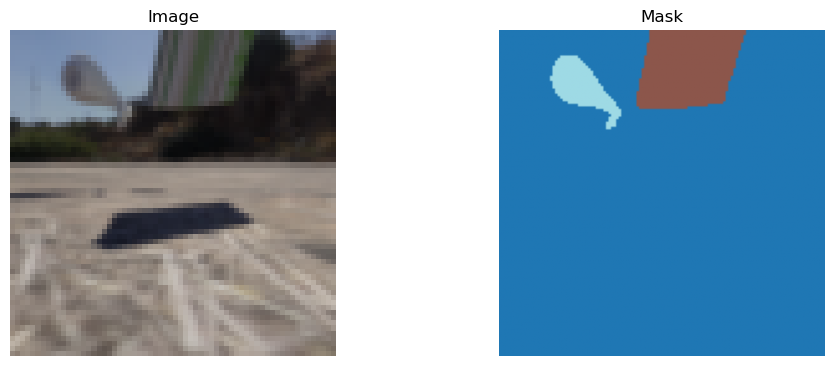

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample["img"].permute(1, 2, 0).numpy())
plt.title("Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sample["mask"].numpy(), cmap="tab20")
plt.title("Mask")
plt.tight_layout()
plt.axis("off")
plt.show()

### Prepare dataset for training an autoencoder

In [5]:
train_dataset = ImageDataset(TRAIN_PATH, transform)
val_dataset = ImageDataset(VALIDATION_PATH, transform)

In [6]:
from torch.utils.data import DataLoader

B_SIZE = 128

train_loader = DataLoader(
        dataset=train_dataset, 
        batch_size=B_SIZE, 
        shuffle=True,
        num_workers=4
) 
val_loader = DataLoader(
        dataset=val_dataset, 
        batch_size=B_SIZE,
        shuffle=False,
        num_workers=4
)

### Define and train an autoencoder

#### Image autoencoder

In [8]:
from autoencoders import ImageAutoencoder
from train_autoencoder import train_autoencoder

autoencoder_img = ImageAutoencoder()

In [9]:
train_loss, val_loss, loss_iters, valid_acc = train_autoencoder(
    model=autoencoder_img, train_loader=train_loader, val_loader=val_loader,
    device=device, mode="img", epochs=15, save_name=MODEL_NAME,
    logger=writer.add_scalar, log_image=writer.add_image)

 27%|██▋       | 4/15 [08:57<24:38, 134.37s/it]


 Epoch 5/15
Validation Loss:  0.0007
Avg SSIM:         0.9240
Avg PSNR:         32.35 dB


 33%|███▎      | 5/15 [11:20<22:54, 137.43s/it]

Saved state to checkpoints/ConvAE.pth


 33%|███▎      | 5/15 [11:43<23:27, 140.75s/it]


KeyboardInterrupt: 

##### Inspect reconstruction of a random sample

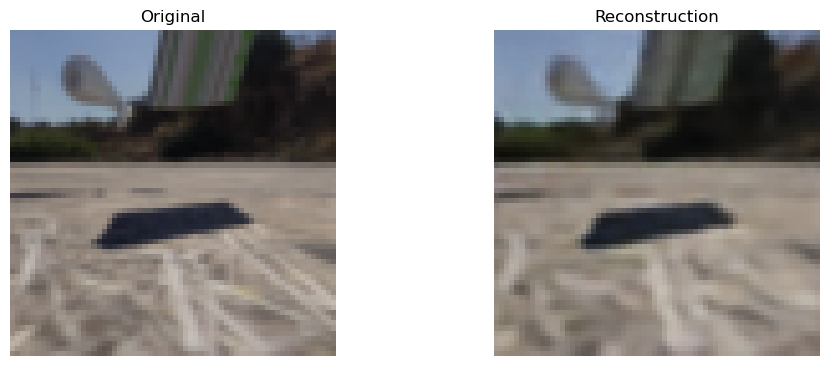

In [10]:
sample = next(iter(val_dataset))['img']
reconstr = autoencoder_img(sample.to(device))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample.permute(1, 2, 0).numpy())
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reconstr.permute(1, 2, 0).detach().cpu().numpy())
plt.title("Reconstruction")
plt.tight_layout()
plt.axis("off")
plt.show()

#### Mask Autoencoder

In [ ]:
# TODO